<a href="https://colab.research.google.com/github/aycaaozturk/AML-project/blob/main/Combined_CoxPH_AML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip install -q lifelines scikit-survival

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 165.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 25.2 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test

from sksurv.util import Surv
from sksurv.metrics import (
    concordance_index_censored,
    cumulative_dynamic_auc,
    integrated_brier_score,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)

BASE_DIR = Path(
    "/content/drive/MyDrive/Uniklinikum Würzburg/AML/"
    "Output Files 2/combined_survival_model_ready_wout_protocol/"
)

TRAIN_PATH = BASE_DIR / "combined_train_survival_model_ready.csv"
VALIDATION_PATH = BASE_DIR / "combined_validation_survival_model_ready.csv"
TEST_PATH = BASE_DIR / "combined_test_survival_model_ready.csv"

OUTPUT_DIR = BASE_DIR / "coxph_results" / "all_combined_features"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Train:", TRAIN_PATH)
print("Validation:", VALIDATION_PATH)
print("Test:", TEST_PATH)
print("Output:", OUTPUT_DIR)

Train: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/combined_train_survival_model_ready.csv
Validation: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/combined_validation_survival_model_ready.csv
Test: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/combined_test_survival_model_ready.csv
Output: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/coxph_results/all_combined_features


In [ ]:
train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

Training shape: (620, 68)
Validation shape: (177, 68)
Test shape: (89, 68)


,PATIENT_ID,AGE,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,PERIPHERAL_BLASTS_PERCENTAGE,WBC_LOG1P,SEX_Female,SEX_Male,RACE_American Indian or Alaska Native,RACE_Asian,RACE_Black or African American,RACE_Native Hawaiian or other Pacific Islander,RACE_Other,RACE_White,ETHNICITY_Hispanic or Latino,ETHNICITY_Not Hispanic or Latino,CNS_DISEASE_No,CNS_DISEASE_Yes,CHLOROMA_No,CHLOROMA_Yes,FAB_M0,FAB_M1,FAB_M2,FAB_M4,FAB_M5,FAB_M6,FAB_M7,FAB_NOS,PRIMARY_CYTOGENETIC_CODE_MLL,PRIMARY_CYTOGENETIC_CODE_Normal,PRIMARY_CYTOGENETIC_CODE_Other,PRIMARY_CYTOGENETIC_CODE_inv(16),PRIMARY_CYTOGENETIC_CODE_t(8;21),RISK_GROUP_CLEAN_High,RISK_GROUP_CLEAN_Low,RISK_GROUP_CLEAN_Missing,RISK_GROUP_CLEAN_Standard,CYTOGENETIC_COMPLEXITY_GROUP_0,CYTOGENETIC_COMPLEXITY_GROUP_1,CYTOGENETIC_COMPLEXITY_GROUP_2,CYTOGENETIC_COMPLEXITY_GROUP_3,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,OS_DAYS,OS_EVENT,SAMPLE_ID,T_6_9,T_8_21,T_3_5_Q25_Q34,T_6_11_Q27_Q23,T_9_11_P22_Q23,T_10_11_P11_2_Q23,T_11_19_Q23_P13_1,INV_16,DEL_5Q,DEL_7Q,DEL_9Q,MONOSOMY_5,MONOSOMY_7,TRISOMY_8,TRISOMY_21,MLL,MINUS_Y,MINUS_X,FLT3_ITD_POSITIVE,FLT3_PM,NPM_MUTATION,CEBPA_MUTATION,WT1_MUTATION,FLT3_ITD_ALLELIC_RATIO_LOG1P
0,TARGET-20-PARNIL,0.805504,0.201872,-0.882435,1.420665,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,TARGET-20-PARNIL-09,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-0.323440
1,TARGET-20-PAPZYS,-0.477096,1.024895,-1.447140,-1.911679,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2566.0,0.0,TARGET-20-PAPZYS-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,-0.323440
2,TARGET-20-PASKUA,0.164204,0.168951,0.623447,0.661814,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,721.0,1.0,TARGET-20-PASKUA-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1.322296
3,TARGET-20-PARMME,0.164204,1.024895,0.466584,-0.435777,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2363.0,0.0,TARGET-20-PARMME-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1.410749
4,TARGET-20-PARTYV,-0.797747,0.613384,0.560702,0.818136,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,406.0,0.0,TARGET-20-PARTYV-09,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,2.110204


In [ ]:
DURATION_COL = "OS_DAYS"
EVENT_COL = "OS_EVENT"

PATIENT_ID_COL = "PATIENT_ID"
SAMPLE_ID_COL = "SAMPLE_ID"

EXCLUDED_COLUMNS = [
    PATIENT_ID_COL,
    SAMPLE_ID_COL,
    DURATION_COL,
    EVENT_COL,
]

candidate_features = [
    column
    for column in train_df.columns
    if column not in EXCLUDED_COLUMNS
]

print("Candidate predictors:", len(candidate_features))
print(candidate_features)

non_numeric_features = [
    column
    for column in candidate_features
    if not pd.api.types.is_numeric_dtype(train_df[column])
]

print("Nonnumeric candidate columns:")
print(non_numeric_features)

if non_numeric_features:
    raise ValueError(
        "The following candidate predictors are nonnumeric:\n"
        + "\n".join(non_numeric_features)
        + "\n\nEither one-hot encode them or add them to "
          "OPTIONAL_METADATA_COLUMNS."
    )



Candidate predictors: 64
['AGE', 'BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE', 'PERIPHERAL_BLASTS_PERCENTAGE', 'WBC_LOG1P', 'SEX_Female', 'SEX_Male', 'RACE_American Indian or Alaska Native', 'RACE_Asian', 'RACE_Black or African American', 'RACE_Native Hawaiian or other Pacific Islander', 'RACE_Other', 'RACE_White', 'ETHNICITY_Hispanic or Latino', 'ETHNICITY_Not Hispanic or Latino', 'CNS_DISEASE_No', 'CNS_DISEASE_Yes', 'CHLOROMA_No', 'CHLOROMA_Yes', 'FAB_M0', 'FAB_M1', 'FAB_M2', 'FAB_M4', 'FAB_M5', 'FAB_M6', 'FAB_M7', 'FAB_NOS', 'PRIMARY_CYTOGENETIC_CODE_MLL', 'PRIMARY_CYTOGENETIC_CODE_Normal', 'PRIMARY_CYTOGENETIC_CODE_Other', 'PRIMARY_CYTOGENETIC_CODE_inv(16)', 'PRIMARY_CYTOGENETIC_CODE_t(8;21)', 'RISK_GROUP_CLEAN_High', 'RISK_GROUP_CLEAN_Low', 'RISK_GROUP_CLEAN_Missing', 'RISK_GROUP_CLEAN_Standard', 'CYTOGENETIC_COMPLEXITY_GROUP_0', 'CYTOGENETIC_COMPLEXITY_GROUP_1', 'CYTOGENETIC_COMPLEXITY_GROUP_2', 'CYTOGENETIC_COMPLEXITY_GROUP_3', 'CYTOGENETIC_COMPLEXITY_GROUP_4_plus', 'T_6_9', 'T_8_21'

In [ ]:
REQUESTED_FEATURES = candidate_features.copy()

print("Total requested model features:", len(REQUESTED_FEATURES))

Total requested model features: 64


In [ ]:
for dataset_name, df in {
    "Training": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():

    required_outcomes = [DURATION_COL, EVENT_COL]

    missing_outcomes = [
        column
        for column in required_outcomes
        if column not in df.columns
    ]

    if missing_outcomes:
        raise ValueError(
            f"{dataset_name} is missing outcome columns: "
            f"{missing_outcomes}"
        )

In [ ]:
def check_feature_columns(
    df: pd.DataFrame,
    dataset_name: str,
    features: list[str]
) -> None:
    missing_features = [
        feature
        for feature in features
        if feature not in df.columns
    ]

    if missing_features:
        raise ValueError(
            f"{dataset_name} is missing these predictors:\n"
            + "\n".join(missing_features)
        )

    print(
        f"{dataset_name}: all {len(features)} "
        "predictors are available."
    )

In [ ]:
check_feature_columns(
    train_df,
    "Training set",
    REQUESTED_FEATURES
)

check_feature_columns(
    validation_df,
    "Validation set",
    REQUESTED_FEATURES
)

check_feature_columns(
    test_df,
    "Test set",
    REQUESTED_FEATURES
)

Training set: all 64 predictors are available.
Validation set: all 64 predictors are available.
Test set: all 64 predictors are available.


In [ ]:
def validate_dataset(
    df: pd.DataFrame,
    dataset_name: str,
    features: list[str]
) -> None:

    if df[DURATION_COL].isna().any():
        raise ValueError(
            f"{dataset_name}: {DURATION_COL} has missing values."
        )

    if df[EVENT_COL].isna().any():
        raise ValueError(
            f"{dataset_name}: {EVENT_COL} has missing values."
        )

    if (df[DURATION_COL] <= 0).any():
        raise ValueError(
            f"{dataset_name}: {DURATION_COL} must be > 0."
        )

    if not df[EVENT_COL].isin([0, 1]).all():
        invalid_values = sorted(
            df.loc[
                ~df[EVENT_COL].isin([0, 1]),
                EVENT_COL
            ].unique()
        )

        raise ValueError(
            f"{dataset_name}: {EVENT_COL} must contain 0/1. "
            f"Invalid values: {invalid_values}"
        )

    missingness = df[features].isna().sum()

    if missingness.sum() > 0:
        print(f"\nMissing predictors in {dataset_name}:")

        display(
            missingness[
                missingness > 0
            ].sort_values(ascending=False)
        )

        raise ValueError(
            f"{dataset_name} still contains missing predictor values."
        )

    print(
        f"{dataset_name}: "
        f"n={len(df)}, "
        f"events={int(df[EVENT_COL].sum())}, "
        f"censored={int((df[EVENT_COL] == 0).sum())}, "
        f"event rate={df[EVENT_COL].mean():.3f}"
    )

In [ ]:
validate_dataset(
    train_df,
    "Training set",
    REQUESTED_FEATURES
)

validate_dataset(
    validation_df,
    "Validation set",
    REQUESTED_FEATURES
)

validate_dataset(
    test_df,
    "Test set",
    REQUESTED_FEATURES
)

Training set: n=620, events=223, censored=397, event rate=0.360
Validation set: n=177, events=63, censored=114, event rate=0.356
Test set: n=89, events=32, censored=57, event rate=0.360


In [ ]:
def check_patient_overlap(
    train_data: pd.DataFrame,
    validation_data: pd.DataFrame,
    test_data: pd.DataFrame
) -> None:

    if PATIENT_ID_COL not in train_data.columns:
        print("PATIENT_ID not available; overlap check skipped.")
        return

    train_ids = set(
        train_data[PATIENT_ID_COL].dropna().astype(str)
    )

    validation_ids = set(
        validation_data[PATIENT_ID_COL].dropna().astype(str)
    )

    test_ids = set(
        test_data[PATIENT_ID_COL].dropna().astype(str)
    )

    overlaps = {
        "Train–Validation": train_ids & validation_ids,
        "Train–Test": train_ids & test_ids,
        "Validation–Test": validation_ids & test_ids,
    }

    overlap_detected = False

    for comparison, overlap in overlaps.items():
        print(f"{comparison} overlap: {len(overlap)}")

        if overlap:
            overlap_detected = True
            print("Example IDs:", list(overlap)[:10])

    if overlap_detected:
        raise ValueError(
            "Patient overlap detected. This would cause data leakage."
        )

    print("No patient overlap detected.")

In [ ]:
check_patient_overlap(
    train_df,
    validation_df,
    test_df
)

Train–Validation overlap: 0
Train–Test overlap: 0
Validation–Test overlap: 0
No patient overlap detected.


In [ ]:
zero_variance_features = [
    feature
    for feature in REQUESTED_FEATURES
    if train_df[feature].nunique(dropna=True) <= 1
]

MODEL_FEATURES = [
    feature
    for feature in REQUESTED_FEATURES
    if feature not in zero_variance_features
]

print("Zero-variance features removed:")
print(zero_variance_features)

print("\nNumber of retained predictors:")
print(len(MODEL_FEATURES))

if not MODEL_FEATURES:
    raise ValueError(
        "No predictors remain after zero-variance filtering."
    )

Zero-variance features removed:
[]

Number of retained predictors:
64


In [ ]:
pd.DataFrame({
    "zero_variance_feature": zero_variance_features
}).to_csv(
    OUTPUT_DIR / "zero_variance_features_removed.csv",
    index=False
)

In [ ]:
def create_feature_summary(
    df: pd.DataFrame,
    features: list[str]
) -> pd.DataFrame:

    rows = []

    for feature in features:
        values = pd.to_numeric(
            df[feature],
            errors="coerce"
        )

        unique_values = values.dropna().unique()
        is_binary = set(unique_values).issubset({0, 1})

        rows.append({
            "feature": feature,
            "n_unique": int(values.nunique()),
            "mean": float(values.mean()),
            "standard_deviation": float(values.std()),
            "minimum": float(values.min()),
            "maximum": float(values.max()),
            "is_binary": bool(is_binary),
            "n_positive": (
                int((values == 1).sum())
                if is_binary
                else np.nan
            ),
            "prevalence": (
                float(values.mean())
                if is_binary
                else np.nan
            ),
        })

    return pd.DataFrame(rows)

In [ ]:
feature_summary_df = create_feature_summary(
    train_df,
    MODEL_FEATURES
)

display(feature_summary_df)

feature_summary_df.to_csv(
    OUTPUT_DIR / "combined_feature_summary.csv",
    index=False
)

,feature,n_unique,mean,standard_deviation,minimum,maximum,is_binary,n_positive,prevalence
0,AGE,26,-1.074409e-16,1.000807,-1.439047,3.210380,False,NaN,NaN
1,BONE_MARROW_LEUKEMIC_BLAST_PERCENTAGE,187,-8.022257e-17,1.000807,-2.678707,1.436406,False,NaN,NaN
2,PERIPHERAL_BLASTS_PERCENTAGE,128,6.912034e-17,1.000807,-1.447140,1.658740,False,NaN,NaN
3,WBC_LOG1P,452,-1.661753e-16,1.000807,-2.533576,2.246302,False,NaN,NaN
4,SEX_Female,2,5.000000e-01,0.500404,0.000000,1.000000,True,310.0,0.500000
5,SEX_Male,2,5.000000e-01,0.500404,0.000000,1.000000,True,310.0,0.500000
6,RACE_American Indian or Alaska Native,2,4.838710e-03,0.069448,0.000000,1.000000,True,3.0,0.004839
7,RACE_Asian,2,5.000000e-02,0.218121,0.000000,1.000000,True,31.0,0.050000
8,RACE_Black or African American,2,1.096774e-01,0.312740,0.000000,1.000000,True,68.0,0.109677
9,RACE_Native Hawaiian or other Pacific Islander,2,3.225806e-03,0.056750,0.000000,1.000000,True,2.0,0.003226


In [ ]:
def prepare_cox_dataframe(
    df: pd.DataFrame,
    features: list[str]
) -> pd.DataFrame:

    model_df = df[
        features + [DURATION_COL, EVENT_COL]
    ].copy()

    for feature in features:
        model_df[feature] = pd.to_numeric(
            model_df[feature],
            errors="raise"
        ).astype(float)

    model_df[DURATION_COL] = pd.to_numeric(
        model_df[DURATION_COL],
        errors="raise"
    ).astype(float)

    model_df[EVENT_COL] = pd.to_numeric(
        model_df[EVENT_COL],
        errors="raise"
    ).astype(int)

    return model_df

In [ ]:
train_model_df = prepare_cox_dataframe(
    train_df,
    MODEL_FEATURES
)

validation_model_df = prepare_cox_dataframe(
    validation_df,
    MODEL_FEATURES
)

test_model_df = prepare_cox_dataframe(
    test_df,
    MODEL_FEATURES
)

print("Train model matrix:", train_model_df.shape)
print("Validation model matrix:", validation_model_df.shape)
print("Test model matrix:", test_model_df.shape)

Train model matrix: (620, 66)
Validation model matrix: (177, 66)
Test model matrix: (89, 66)


In [ ]:
def prepare_survival_array(
    df: pd.DataFrame
) -> np.ndarray:

    return Surv.from_arrays(
        event=df[EVENT_COL].astype(bool).to_numpy(),
        time=df[DURATION_COL].astype(float).to_numpy()
    )

In [ ]:
y_train = prepare_survival_array(train_df)
y_validation = prepare_survival_array(validation_df)
y_test = prepare_survival_array(test_df)

In [ ]:
COX_CONFIGURATIONS = [
    {
        "configuration": "Standard Cox",
        "penalizer": 0.00,
        "l1_ratio": 0.00,
    },
    {
        "configuration": "Ridge 0.01",
        "penalizer": 0.01,
        "l1_ratio": 0.00,
    },
    {
        "configuration": "Elastic Net 0.10",
        "penalizer": 0.10,
        "l1_ratio": 0.50,
    },
    {
        "configuration": "LASSO 0.10",
        "penalizer": 0.10,
        "l1_ratio": 1.00,
    },
]

display(pd.DataFrame(COX_CONFIGURATIONS))

,configuration,penalizer,l1_ratio
0,Standard Cox,0.00,0.0
1,Ridge 0.01,0.01,0.0
2,Elastic Net 0.10,0.10,0.5
3,LASSO 0.10,0.10,1.0


In [ ]:
# COX_CONFIGURATIONS = [
#     {"configuration": "Standard Cox",
#      "penalizer": 0.00, "l1_ratio": 0.00},
#
#     {"configuration": "Ridge 0.001",
#      "penalizer": 0.001, "l1_ratio": 0.00},
#
#     {"configuration": "Ridge 0.01",
#      "penalizer": 0.01, "l1_ratio": 0.00},
#
#     {"configuration": "Ridge 0.10",
#      "penalizer": 0.10, "l1_ratio": 0.00},
#
#     {"configuration": "Elastic Net 0.01",
#      "penalizer": 0.01, "l1_ratio": 0.50},
#
#     {"configuration": "Elastic Net 0.10",
#      "penalizer": 0.10, "l1_ratio": 0.50},
#
#     {"configuration": "LASSO 0.01",
#      "penalizer": 0.01, "l1_ratio": 1.00},
#
#     {"configuration": "LASSO 0.10",
#      "penalizer": 0.10, "l1_ratio": 1.00},
# ]

In [ ]:
def predict_risk_scores(
    model: CoxPHFitter,
    model_df: pd.DataFrame
) -> np.ndarray:

    scores = model.predict_partial_hazard(
        model_df[MODEL_FEATURES]
    )

    return scores.to_numpy().reshape(-1)

In [ ]:
def calculate_c_index(
    model: CoxPHFitter,
    model_df: pd.DataFrame,
    survival_array: np.ndarray
) -> tuple[float, np.ndarray]:

    risk_scores = predict_risk_scores(
        model,
        model_df
    )

    c_index = concordance_index_censored(
        survival_array["event"],
        survival_array["time"],
        risk_scores
    )[0]

    return float(c_index), risk_scores

In [ ]:
REQUESTED_AUC_TIMES = np.array(
    [
        365,
        730,
        1095,
        1825,
    ],
    dtype=float
)

In [ ]:
def get_valid_evaluation_times(
    requested_times: np.ndarray,
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray
) -> np.ndarray:

    lower_bound = max(
        float(training_survival["time"].min()),
        float(evaluation_survival["time"].min())
    )

    upper_bound = min(
        float(training_survival["time"].max()),
        float(evaluation_survival["time"].max())
    )

    valid_times = requested_times[
        (requested_times > lower_bound)
        & (requested_times < upper_bound)
    ]

    if len(valid_times) == 0:
        raise ValueError(
            "None of the requested AUC times are supported."
        )

    return valid_times

In [ ]:
def calculate_time_dependent_auc(
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray,
    risk_scores: np.ndarray,
    requested_times: np.ndarray
) -> tuple[pd.DataFrame, float]:

    valid_times = get_valid_evaluation_times(
        requested_times,
        training_survival,
        evaluation_survival
    )

    auc_values, mean_auc = cumulative_dynamic_auc(
        training_survival,
        evaluation_survival,
        risk_scores,
        valid_times
    )

    auc_df = pd.DataFrame({
        "time_days": valid_times,
        "time_years": valid_times / 365.25,
        "auc": auc_values,
    })

    return auc_df, float(mean_auc)

In [ ]:
def create_brier_time_grid(
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray,
    n_times: int = 100
) -> np.ndarray:

    lower_bound = max(
        float(training_survival["time"].min()),
        float(evaluation_survival["time"].min())
    )

    upper_bound = min(
        float(training_survival["time"].max()),
        float(evaluation_survival["time"].max())
    )

    evaluation_times = evaluation_survival["time"]

    start = max(
        lower_bound + 1,
        float(np.quantile(evaluation_times, 0.10))
    )

    stop = min(
        upper_bound - 1,
        float(np.quantile(evaluation_times, 0.90))
    )

    if start >= stop:
        raise ValueError(
            "A valid IBS time range could not be constructed."
        )

    return np.linspace(start, stop, n_times)

In [ ]:
def predict_survival_probability_matrix(
    model: CoxPHFitter,
    model_df: pd.DataFrame,
    times: np.ndarray
) -> np.ndarray:

    predictions = model.predict_survival_function(
        model_df[MODEL_FEATURES],
        times=times
    )

    return predictions.to_numpy().T

In [ ]:
def calculate_integrated_brier_score(
    model: CoxPHFitter,
    model_df: pd.DataFrame,
    training_survival: np.ndarray,
    evaluation_survival: np.ndarray
) -> tuple[float, np.ndarray]:

    brier_times = create_brier_time_grid(
        training_survival,
        evaluation_survival
    )

    survival_probabilities = (
        predict_survival_probability_matrix(
            model,
            model_df,
            brier_times
        )
    )

    ibs = integrated_brier_score(
        training_survival,
        evaluation_survival,
        survival_probabilities,
        brier_times
    )

    return float(ibs), brier_times

In [ ]:
configuration_results = []
fitted_models = {}
auc_results = {}

for config in COX_CONFIGURATIONS:
    configuration_name = config["configuration"]

    print("\n" + "=" * 75)
    print("Training:", configuration_name)
    print("Features:", len(MODEL_FEATURES))
    print("Penalizer:", config["penalizer"])
    print("L1 ratio:", config["l1_ratio"])
    print("=" * 75)

    try:
        model = CoxPHFitter(
            penalizer=config["penalizer"],
            l1_ratio=config["l1_ratio"]
        )

        model.fit(
            train_model_df,
            duration_col=DURATION_COL,
            event_col=EVENT_COL,
            show_progress=False
        )

        # C-index
        train_c_index, train_risk_scores = (
            calculate_c_index(
                model,
                train_model_df,
                y_train
            )
        )

        validation_c_index, validation_risk_scores = (
            calculate_c_index(
                model,
                validation_model_df,
                y_validation
            )
        )

        test_c_index, test_risk_scores = (
            calculate_c_index(
                model,
                test_model_df,
                y_test
            )
        )

        # Time-dependent AUC
        validation_auc_df, validation_mean_auc = (
            calculate_time_dependent_auc(
                y_train,
                y_validation,
                validation_risk_scores,
                REQUESTED_AUC_TIMES
            )
        )

        test_auc_df, test_mean_auc = (
            calculate_time_dependent_auc(
                y_train,
                y_test,
                test_risk_scores,
                REQUESTED_AUC_TIMES
            )
        )

        # IBS
        validation_ibs, validation_brier_times = (
            calculate_integrated_brier_score(
                model,
                validation_model_df,
                y_train,
                y_validation
            )
        )

        test_ibs, test_brier_times = (
            calculate_integrated_brier_score(
                model,
                test_model_df,
                y_train,
                y_test
            )
        )

        print(f"Train C-index: {train_c_index:.4f}")

        print(f"Validation C-index: {validation_c_index:.4f}")
        print(f"Validation IBS: {validation_ibs:.4f}")
        print(f"Validation mean AUC: {validation_mean_auc:.4f}")

        print(f"Test C-index: {test_c_index:.4f}")
        print(f"Test IBS: {test_ibs:.4f}")
        print(f"Test mean AUC: {test_mean_auc:.4f}")

        configuration_results.append({
            "feature_set": "All Combined Features",
            "configuration": configuration_name,
            "penalizer": config["penalizer"],
            "l1_ratio": config["l1_ratio"],
            "n_requested_features": len(REQUESTED_FEATURES),
            "n_used_features": len(MODEL_FEATURES),

            "train_c_index": train_c_index,
            "validation_c_index": validation_c_index,
            "test_c_index": test_c_index,

            "train_validation_gap":
                train_c_index - validation_c_index,

            "validation_ibs": validation_ibs,
            "test_ibs": test_ibs,

            "validation_mean_auc": validation_mean_auc,
            "test_mean_auc": test_mean_auc,

            "partial_aic": model.AIC_partial_,
            "converged": True,
            "error": None,
        })

        fitted_models[configuration_name] = model

        auc_results[configuration_name] = {
            "validation": validation_auc_df,
            "test": test_auc_df,
        }

    except Exception as error:
        print(
            f"Configuration '{configuration_name}' failed: {error}"
        )

        configuration_results.append({
            "feature_set": "All Combined Features",
            "configuration": configuration_name,
            "penalizer": config["penalizer"],
            "l1_ratio": config["l1_ratio"],
            "n_requested_features": len(REQUESTED_FEATURES),
            "n_used_features": len(MODEL_FEATURES),

            "train_c_index": np.nan,
            "validation_c_index": np.nan,
            "test_c_index": np.nan,

            "train_validation_gap": np.nan,

            "validation_ibs": np.nan,
            "test_ibs": np.nan,

            "validation_mean_auc": np.nan,
            "test_mean_auc": np.nan,

            "partial_aic": np.nan,
            "converged": False,
            "error": str(error),
        })


Training: Standard Cox
Features: 64
Penalizer: 0.0
L1 ratio: 0.0
Configuration 'Standard Cox' failed: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.

Training: Ridge 0.01
Features: 64
Penalizer: 0.01
L1 ratio: 0.0
Train C-index: 0.7062
Validation C-index: 0.6567
Validation IBS: 0.1891
Validation mean AUC: 0.6541
Test C-index: 0.6005
Test IBS: 0.2005
Test mean AUC: 0.6436

Training: Elastic Net 0.10
Features: 64
Penalizer: 0.1
L1 ratio: 0.5
Train C-index: 0.6657
Validation C-index: 0.6663
Validation IBS: 0.1987
Validation mean AUC: 0.7010
Test C-index: 0.6877
Test IBS: 0.1867
Test mean AUC: 0.7436

Training: LASSO 0.10
Features: 64
Penalizer: 0.1
L1 ratio: 1.0
Configuration 'LASSO 0.10' failed: Convergence halted due to matrix inversion problems. Susp

In [ ]:
configuration_results_df = pd.DataFrame(
    configuration_results
)

configuration_results_df = (
    configuration_results_df
    .sort_values(
        by=[
            "validation_c_index",
            "validation_ibs",
            "validation_mean_auc",
            "train_validation_gap",
        ],
        ascending=[
            False,
            True,
            False,
            True,
        ]
    )
    .reset_index(drop=True)
)

display(configuration_results_df)

,feature_set,configuration,penalizer,l1_ratio,n_requested_features,n_used_features,train_c_index,validation_c_index,test_c_index,train_validation_gap,validation_ibs,test_ibs,validation_mean_auc,test_mean_auc,partial_aic,converged,error
0,All Combined Features,Elastic Net 0.10,0.10,0.5,64,64,0.665743,0.666290,0.687699,-0.000548,0.198735,0.186741,0.701015,0.743643,2851.959539,True,None
1,All Combined Features,Ridge 0.01,0.01,0.0,64,64,0.706178,0.656698,0.600545,0.049480,0.189116,0.200476,0.654054,0.643552,3569.586070,True,None
2,All Combined Features,Standard Cox,0.00,0.0,64,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Convergence halted due to matrix inversion pro...
3,All Combined Features,LASSO 0.10,0.10,1.0,64,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,Convergence halted due to matrix inversion pro...


In [ ]:
configuration_results_df.to_csv(
    OUTPUT_DIR / "coxph_all_combined_configuration_results.csv",
    index=False
)

In [ ]:
successful_results_df = configuration_results_df.loc[
    configuration_results_df["converged"]
].copy()

if successful_results_df.empty:
    raise RuntimeError(
        "No Cox PH configuration completed successfully."
    )

best_result = successful_results_df.iloc[0]

BEST_CONFIGURATION = best_result["configuration"]
best_model = fitted_models[BEST_CONFIGURATION]

print("=" * 75)
print("SELECTED COX PH MODEL")
print("=" * 75)

print("Configuration:", BEST_CONFIGURATION)
print("Features used:", len(MODEL_FEATURES))
print("Penalizer:", best_result["penalizer"])
print("L1 ratio:", best_result["l1_ratio"])

print(
    "Validation C-index:",
    round(best_result["validation_c_index"], 4)
)

print(
    "Validation IBS:",
    round(best_result["validation_ibs"], 4)
)

print(
    "Validation mean AUC:",
    round(best_result["validation_mean_auc"], 4)
)

SELECTED COX PH MODEL
Configuration: Elastic Net 0.10
Features used: 64
Penalizer: 0.1
L1 ratio: 0.5
Validation C-index: 0.6663
Validation IBS: 0.1987
Validation mean AUC: 0.701


In [ ]:
train_c_index, train_risk_scores = calculate_c_index(
    best_model,
    train_model_df,
    y_train
)

validation_c_index, validation_risk_scores = (
    calculate_c_index(
        best_model,
        validation_model_df,
        y_validation
    )
)

test_c_index, test_risk_scores = calculate_c_index(
    best_model,
    test_model_df,
    y_test
)

In [ ]:
validation_auc_df, validation_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_validation,
        validation_risk_scores,
        REQUESTED_AUC_TIMES
    )
)

test_auc_df, test_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_test,
        test_risk_scores,
        REQUESTED_AUC_TIMES
    )
)

In [ ]:
validation_auc_df, validation_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_validation,
        validation_risk_scores,
        REQUESTED_AUC_TIMES
    )
)

test_auc_df, test_mean_auc = (
    calculate_time_dependent_auc(
        y_train,
        y_test,
        test_risk_scores,
        REQUESTED_AUC_TIMES
    )
)

In [ ]:
final_metrics_df = pd.DataFrame({
    "model": [
        "Cox PH",
        "Cox PH",
        "Cox PH",
    ],
    "feature_set": [
        "All Combined Features",
        "All Combined Features",
        "All Combined Features",
    ],
    "configuration": [
        BEST_CONFIGURATION,
        BEST_CONFIGURATION,
        BEST_CONFIGURATION,
    ],
    "dataset": [
        "Training",
        "Validation",
        "Test",
    ],
    "n_patients": [
        len(train_df),
        len(validation_df),
        len(test_df),
    ],
    "n_events": [
        int(train_df[EVENT_COL].sum()),
        int(validation_df[EVENT_COL].sum()),
        int(test_df[EVENT_COL].sum()),
    ],
    "n_features": [
        len(MODEL_FEATURES),
        len(MODEL_FEATURES),
        len(MODEL_FEATURES),
    ],
    "c_index": [
        train_c_index,
        validation_c_index,
        test_c_index,
    ],
    "integrated_brier_score": [
        np.nan,
        validation_ibs,
        test_ibs,
    ],
    "mean_time_dependent_auc": [
        np.nan,
        validation_mean_auc,
        test_mean_auc,
    ],
    "partial_aic_training": [
        best_model.AIC_partial_,
        best_model.AIC_partial_,
        best_model.AIC_partial_,
    ],
})

display(final_metrics_df)

,model,feature_set,configuration,dataset,n_patients,n_events,n_features,c_index,integrated_brier_score,mean_time_dependent_auc,partial_aic_training
0,Cox PH,All Combined Features,Elastic Net 0.10,Training,620,223,64,0.665743,NaN,NaN,2851.959539
1,Cox PH,All Combined Features,Elastic Net 0.10,Validation,177,63,64,0.666290,0.198735,0.701015,2851.959539
2,Cox PH,All Combined Features,Elastic Net 0.10,Test,89,32,64,0.687699,0.186741,0.743643,2851.959539


In [ ]:
final_metrics_df.to_csv(
    OUTPUT_DIR / "coxph_all_combined_final_metrics.csv",
    index=False
)

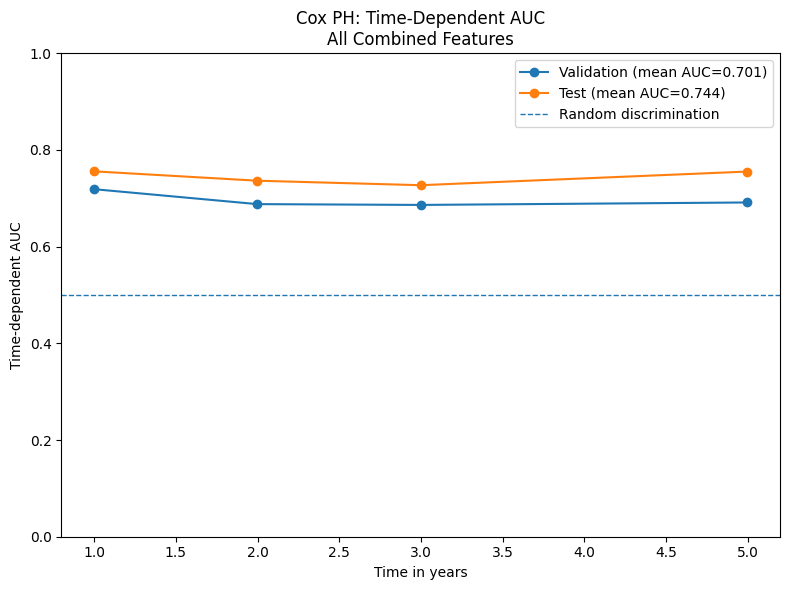

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    validation_auc_df["time_years"],
    validation_auc_df["auc"],
    marker="o",
    label=(
        f"Validation "
        f"(mean AUC={validation_mean_auc:.3f})"
    )
)

plt.plot(
    test_auc_df["time_years"],
    test_auc_df["auc"],
    marker="o",
    label=(
        f"Test "
        f"(mean AUC={test_mean_auc:.3f})"
    )
)

plt.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1,
    label="Random discrimination"
)

plt.xlabel("Time in years")
plt.ylabel("Time-dependent AUC")
plt.title(
    "Cox PH: Time-Dependent AUC\n"
    "All Combined Features"
)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "coxph_all_combined_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
coefficient_df = (
    best_model
    .summary
    .reset_index()
)

coefficient_df = coefficient_df.rename(
    columns={
        "covariate": "feature",
        "coef": "coefficient",
        "exp(coef)": "hazard_ratio",
        "exp(coef) lower 95%": "hr_ci_lower",
        "exp(coef) upper 95%": "hr_ci_upper",
        "p": "p_value",
    }
)

coefficient_df = coefficient_df[
    [
        "feature",
        "coefficient",
        "hazard_ratio",
        "hr_ci_lower",
        "hr_ci_upper",
        "p_value",
    ]
].copy()

coefficient_df["absolute_coefficient"] = (
    coefficient_df["coefficient"].abs()
)

coefficient_df = coefficient_df.sort_values(
    "absolute_coefficient",
    ascending=False
).reset_index(drop=True)

display(coefficient_df)

,feature,coefficient,hazard_ratio,hr_ci_lower,hr_ci_upper,p_value,absolute_coefficient
0,RISK_GROUP_CLEAN_Low,-5.349295e-01,0.585711,0.438220,0.782842,0.000301,5.349295e-01
1,RACE_Black or African American,3.795428e-01,1.461616,0.912950,2.340021,0.113954,3.795428e-01
2,MONOSOMY_7,2.326481e-01,1.261937,0.555384,2.867362,0.578504,2.326481e-01
3,DEL_7Q,1.601437e-01,1.173679,0.393025,3.504926,0.774189,1.601437e-01
4,RACE_White,-9.233315e-02,0.911801,0.627635,1.324626,0.627981,9.233315e-02
5,CYTOGENETIC_COMPLEXITY_GROUP_4_plus,6.386657e-02,1.065950,0.696674,1.630964,0.768512,6.386657e-02
6,WT1_MUTATION,5.431339e-02,1.055815,0.625625,1.781811,0.838808,5.431339e-02
7,PRIMARY_CYTOGENETIC_CODE_Other,5.229723e-02,1.053689,0.793576,1.399059,0.717687,5.229723e-02
8,T_6_11_Q27_Q23,1.329965e-02,1.013388,0.359292,2.858280,0.979944,1.329965e-02
9,PERIPHERAL_BLASTS_PERCENTAGE,5.578710e-03,1.005594,0.869774,1.162623,0.939932,5.578710e-03


In [ ]:
coefficient_df.to_csv(
    OUTPUT_DIR / "coxph_all_combined_coefficients.csv",
    index=False
)

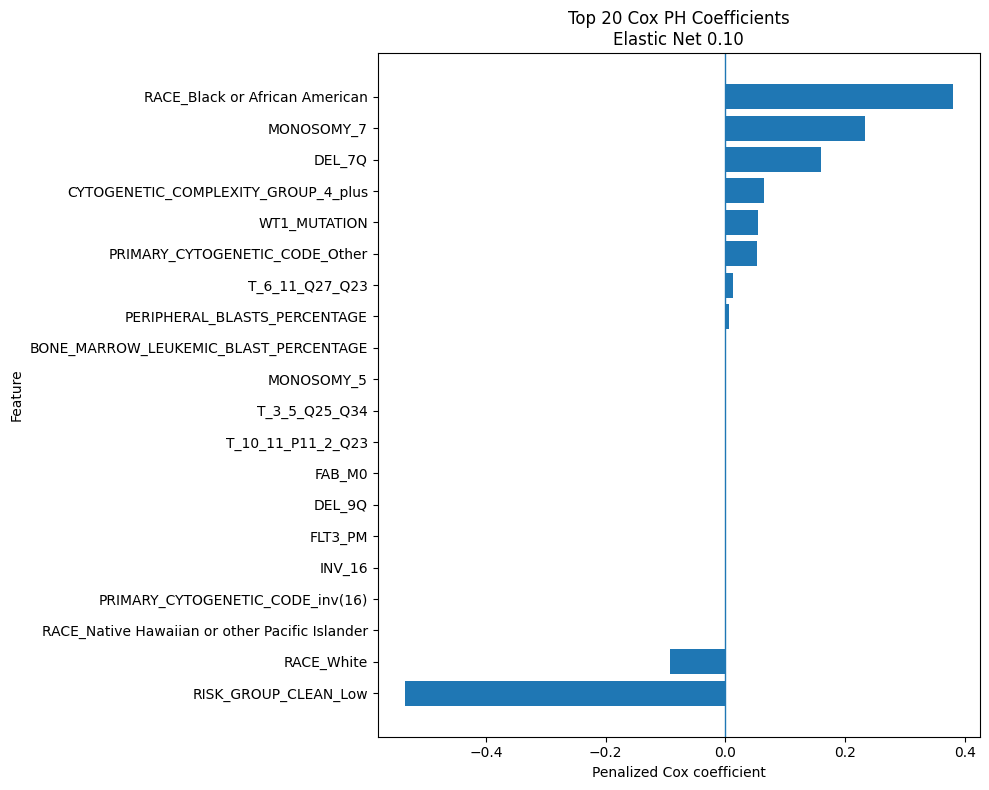

In [ ]:
TOP_N = min(20, len(coefficient_df))

coefficient_plot_df = (
    coefficient_df
    .head(TOP_N)
    .sort_values("coefficient")
)

plt.figure(
    figsize=(
        10,
        max(7, TOP_N * 0.4)
    )
)

plt.barh(
    coefficient_plot_df["feature"],
    coefficient_plot_df["coefficient"]
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.xlabel("Penalized Cox coefficient")
plt.ylabel("Feature")
plt.title(
    f"Top {TOP_N} Cox PH Coefficients\n"
    f"{BEST_CONFIGURATION}"
)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "coxph_all_combined_top_coefficients.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

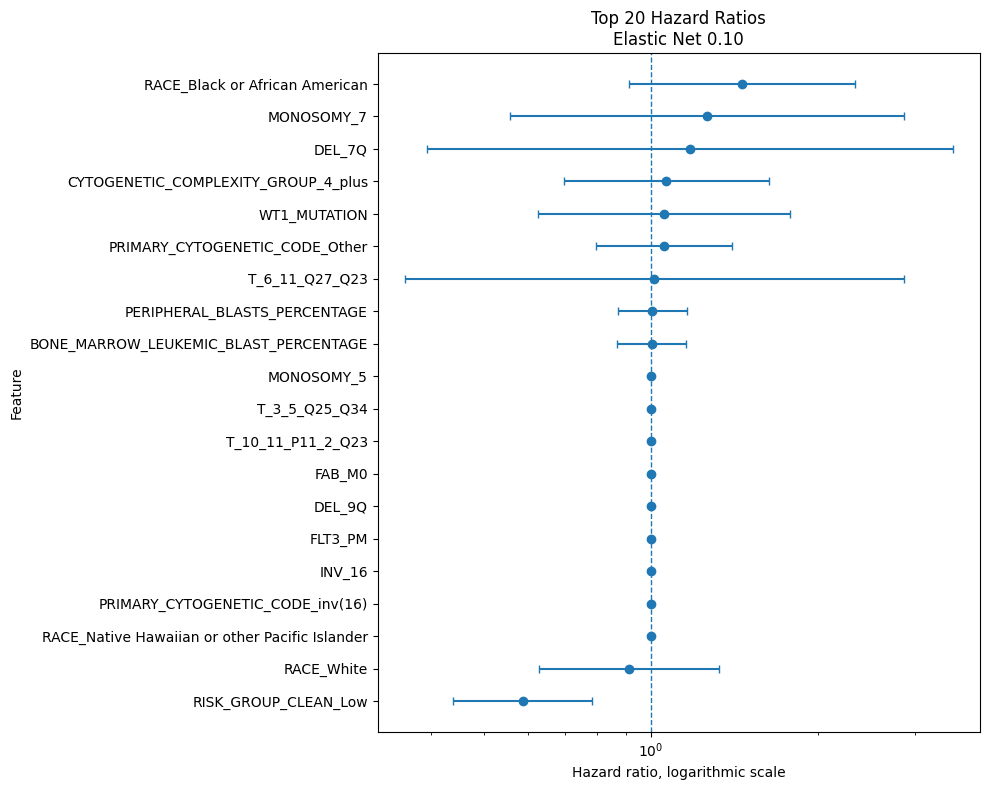

In [ ]:
forest_df = coefficient_df.loc[
    (coefficient_df["hazard_ratio"] > 0)
    & np.isfinite(coefficient_df["hazard_ratio"])
    & np.isfinite(coefficient_df["hr_ci_lower"])
    & np.isfinite(coefficient_df["hr_ci_upper"])
].copy()

forest_df = (
    forest_df
    .head(TOP_N)
    .sort_values("hazard_ratio")
)

lower_error = (
    forest_df["hazard_ratio"]
    - forest_df["hr_ci_lower"]
).clip(lower=0)

upper_error = (
    forest_df["hr_ci_upper"]
    - forest_df["hazard_ratio"]
).clip(lower=0)
plt.figure(
    figsize=(
        10,
        max(7, len(forest_df) * 0.4)
    )
)

plt.errorbar(
    forest_df["hazard_ratio"],
    forest_df["feature"],
    xerr=np.vstack([
        lower_error,
        upper_error
    ]),
    fmt="o",
    capsize=3
)

plt.axvline(
    x=1,
    linestyle="--",
    linewidth=1
)

plt.xscale("log")

plt.xlabel("Hazard ratio, logarithmic scale")
plt.ylabel("Feature")
plt.title(
    f"Top {len(forest_df)} Hazard Ratios\n"
    f"{BEST_CONFIGURATION}"
)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "coxph_all_combined_hazard_ratio_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Training risk cutoff: 1.118739973847516


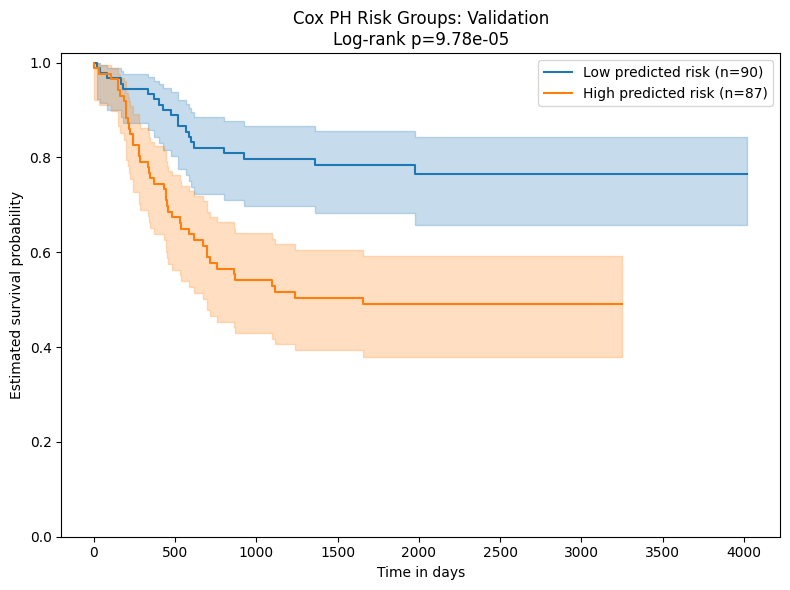

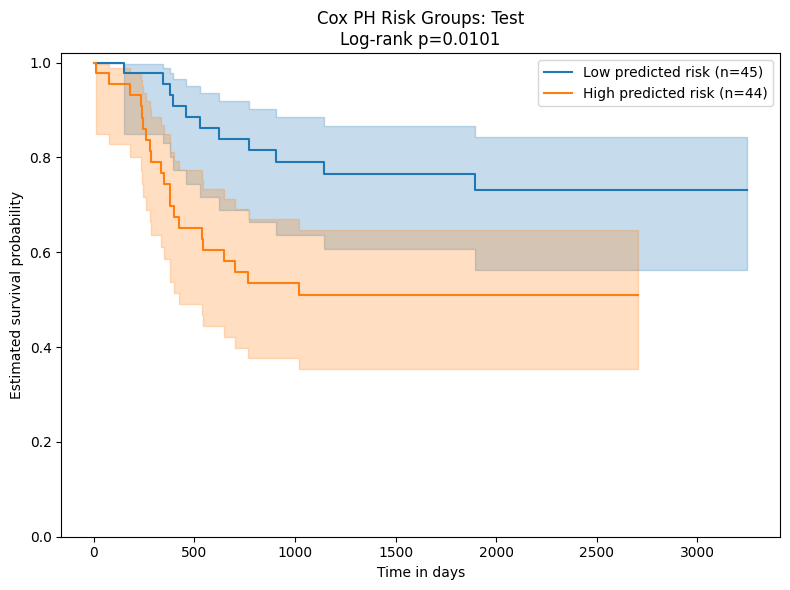

In [ ]:
TRAINING_RISK_CUTOFF = float(
    np.median(train_risk_scores)
)

print("Training risk cutoff:", TRAINING_RISK_CUTOFF)
def plot_km_by_predicted_risk(
    original_df: pd.DataFrame,
    risk_scores: np.ndarray,
    cutoff: float,
    dataset_name: str
) -> tuple[pd.DataFrame, float]:

    plot_df = original_df[
        [DURATION_COL, EVENT_COL]
    ].copy()

    plot_df["predicted_risk"] = risk_scores

    plot_df["risk_group"] = np.where(
        plot_df["predicted_risk"] >= cutoff,
        "High predicted risk",
        "Low predicted risk"
    )

    low_df = plot_df.loc[
        plot_df["risk_group"] == "Low predicted risk"
    ]

    high_df = plot_df.loc[
        plot_df["risk_group"] == "High predicted risk"
    ]

    logrank_result = logrank_test(
        low_df[DURATION_COL],
        high_df[DURATION_COL],
        event_observed_A=low_df[EVENT_COL],
        event_observed_B=high_df[EVENT_COL]
    )

    plt.figure(figsize=(8, 6))

    for group_name in [
        "Low predicted risk",
        "High predicted risk",
    ]:
        group_df = plot_df.loc[
            plot_df["risk_group"] == group_name
        ]

        kmf = KaplanMeierFitter()

        kmf.fit(
            durations=group_df[DURATION_COL],
            event_observed=group_df[EVENT_COL],
            label=f"{group_name} (n={len(group_df)})"
        )

        kmf.plot_survival_function(
            ci_show=True
        )

    plt.xlabel("Time in days")
    plt.ylabel("Estimated survival probability")
    plt.title(
        f"Cox PH Risk Groups: {dataset_name}\n"
        f"Log-rank p={logrank_result.p_value:.3g}"
    )
    plt.ylim(0, 1.02)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"coxph_all_combined_{dataset_name.lower()}_km.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return plot_df, float(logrank_result.p_value)
validation_risk_group_df, validation_logrank_p = (
    plot_km_by_predicted_risk(
        validation_df,
        validation_risk_scores,
        TRAINING_RISK_CUTOFF,
        "Validation"
    )
)

test_risk_group_df, test_logrank_p = (
    plot_km_by_predicted_risk(
        test_df,
        test_risk_scores,
        TRAINING_RISK_CUTOFF,
        "Test"
    )
)

In [ ]:
def create_prediction_table(
    original_df: pd.DataFrame,
    model_df: pd.DataFrame,
    risk_scores: np.ndarray,
    dataset_name: str
) -> pd.DataFrame:

    prediction_df = pd.DataFrame({
        DURATION_COL:
            original_df[DURATION_COL].to_numpy(),
        EVENT_COL:
            original_df[EVENT_COL].to_numpy(),
        "predicted_risk":
            risk_scores,
        "predicted_survival_1_year":
            predict_survival_at_time(
                best_model,
                model_df,
                365.0
            ),
        "predicted_survival_2_years":
            predict_survival_at_time(
                best_model,
                model_df,
                730.0
            ),
        "predicted_survival_3_years":
            predict_survival_at_time(
                best_model,
                model_df,
                1095.0
            ),
        "risk_group": np.where(
            risk_scores >= TRAINING_RISK_CUTOFF,
            "High predicted risk",
            "Low predicted risk"
        ),
        "dataset": dataset_name,
        "configuration": BEST_CONFIGURATION,
    })

    if PATIENT_ID_COL in original_df.columns:
        prediction_df.insert(
            0,
            PATIENT_ID_COL,
            original_df[PATIENT_ID_COL].to_numpy()
        )

    if SAMPLE_ID_COL in original_df.columns:
        position = (
            1
            if PATIENT_ID_COL in prediction_df.columns
            else 0
        )

        prediction_df.insert(
            position,
            SAMPLE_ID_COL,
            original_df[SAMPLE_ID_COL].to_numpy()
        )

    return prediction_df
train_predictions_df = create_prediction_table(
    train_df,
    train_model_df,
    train_risk_scores,
    "Training"
)

validation_predictions_df = create_prediction_table(
    validation_df,
    validation_model_df,
    validation_risk_scores,
    "Validation"
)

test_predictions_df = create_prediction_table(
    test_df,
    test_model_df,
    test_risk_scores,
    "Test"
)

all_predictions_df = pd.concat(
    [
        train_predictions_df,
        validation_predictions_df,
        test_predictions_df,
    ],
    ignore_index=True
)

display(all_predictions_df.head())
all_predictions_df.to_csv(
    OUTPUT_DIR / "coxph_all_combined_patient_predictions.csv",
    index=False
)

NameError: name 'predict_survival_at_time' is not defined

In [ ]:
MODEL_PATH = OUTPUT_DIR / "coxph_all_combined_model.pkl"

with open(MODEL_PATH, "wb") as file:
    pickle.dump(best_model, file)
configuration = {
    "model": "Cox proportional hazards",
    "feature_set": "All Combined Features",
    "requested_features": REQUESTED_FEATURES,
    "used_features": MODEL_FEATURES,
    "excluded_columns": EXCLUDED_COLUMNS,
    "zero_variance_features_removed":
        zero_variance_features,
    "selected_configuration":
        BEST_CONFIGURATION,
    "penalizer":
        float(best_result["penalizer"]),
    "l1_ratio":
        float(best_result["l1_ratio"]),
    "duration_column":
        DURATION_COL,
    "event_column":
        EVENT_COL,
    "number_of_features":
        len(MODEL_FEATURES),
    "auc_times_days":
        REQUESTED_AUC_TIMES.tolist(),
    "training_risk_cutoff":
        TRAINING_RISK_CUTOFF,
    "selection_rule": (
        "Highest validation C-index, followed by "
        "lowest validation IBS, highest validation mean AUC, "
        "and smallest train-validation C-index gap."
    ),
}
CONFIGURATION_PATH = (
    OUTPUT_DIR / "coxph_all_combined_configuration.json"
)

with open(CONFIGURATION_PATH, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

print("Model saved to:", MODEL_PATH)
print("Configuration saved to:", CONFIGURATION_PATH)

Model saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/coxph_results/all_combined_features/coxph_all_combined_model.pkl
Configuration saved to: /content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/coxph_results/all_combined_features/coxph_all_combined_configuration.json


In [ ]:
print("\n" + "=" * 75)
print("FINAL COX PH RESULTS — ALL COMBINED FEATURES")
print("=" * 75)

print("Selected configuration:", BEST_CONFIGURATION)
print("Predictors used:", len(MODEL_FEATURES))

print("\nValidation")
print(f"C-index: {validation_c_index:.4f}")
print(f"IBS: {validation_ibs:.4f}")
print(f"Mean AUC: {validation_mean_auc:.4f}")

print("\nTest")
print(f"C-index: {test_c_index:.4f}")
print(f"IBS: {test_ibs:.4f}")
print(f"Mean AUC: {test_mean_auc:.4f}")

print("\nOutputs:")
print(OUTPUT_DIR)

print("=" * 75)


FINAL COX PH RESULTS — ALL COMBINED FEATURES
Selected configuration: Elastic Net 0.10
Predictors used: 64

Validation
C-index: 0.6663
IBS: 0.1987
Mean AUC: 0.7010

Test
C-index: 0.6877
IBS: 0.1867
Mean AUC: 0.7436

Outputs:
/content/drive/MyDrive/Uniklinikum Würzburg/AML/Output Files 2/combined_survival_model_ready_wout_protocol/coxph_results/all_combined_features
